# 04. Stationarity Diagnostics for Quarterly Thailand Data

The monthly specification showed unresolved or I(2)-type behavior for several macro variables. The dataset has now been converted to quarterly frequency, and this notebook re-runs stationarity diagnostics under the quarterly specification.

Scope: diagnostics only (no lag selection, VAR, SVAR, or VECM estimation).

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# Optional Phillips-Perron support
try:
    from arch.unitroot import PhillipsPerron
    HAS_PP = True
except Exception:
    HAS_PP = False

plt.rcParams['figure.dpi'] = 150
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)
print('Phillips-Perron available:', HAS_PP)

Phillips-Perron available: True


## 1. Load and Inspect Quarterly Data

In [2]:
# Load quarterly dataset
data_path = '../../data/processed/THA_model_ready_quarterly.csv'
df = pd.read_csv(data_path, parse_dates=['date'], index_col='date')

# Ensure datetime index and sorting
df.index = pd.to_datetime(df.index)
df = df.sort_index()

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Date range:', df.index.min(), 'to', df.index.max())
print('Index dtype:', df.index.dtype)
print('Index is monotonic increasing:', df.index.is_monotonic_increasing)
print('Missing values:')
print(df.isnull().sum())
print('Head:')
print(df.head())

Shape: (73, 5)
Columns: ['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']
Date range: 2006-03-31 00:00:00 to 2024-03-31 00:00:00
Index dtype: datetime64[us]
Index is monotonic increasing: True
Missing values:
ln_WTI      0
ln_GDP      0
ln_CPI      0
Interest    0
ln_FX       0
dtype: int64
Head:
             ln_WTI    ln_GDP   ln_CPI  Interest    ln_FX
date                                                     
2006-03-31 4.147038 26.155337 4.508159  6.254871 3.627030
2006-06-30 4.254329 26.199388 4.513737  6.198061 3.604410
2006-09-30 4.252125 26.241580 4.519283  6.141251 3.581267
2006-12-31 4.093711 26.282063 4.524800  6.084442 3.557576
2007-03-31 4.060750 26.313068 4.533001  6.027845 3.538570


## 2. Visual Inspection (Levels)

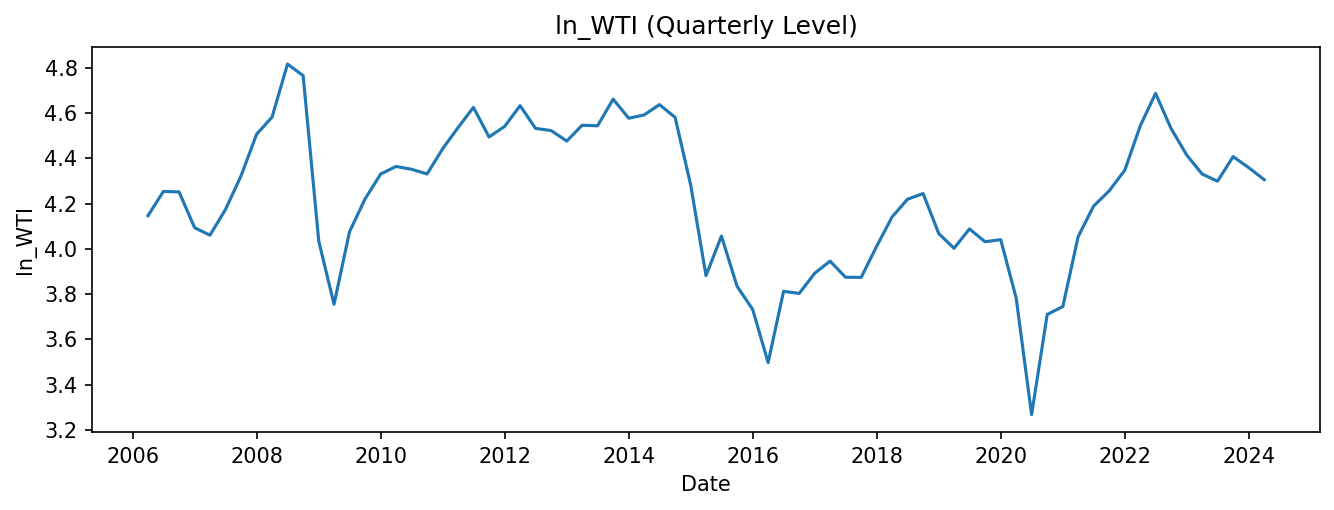

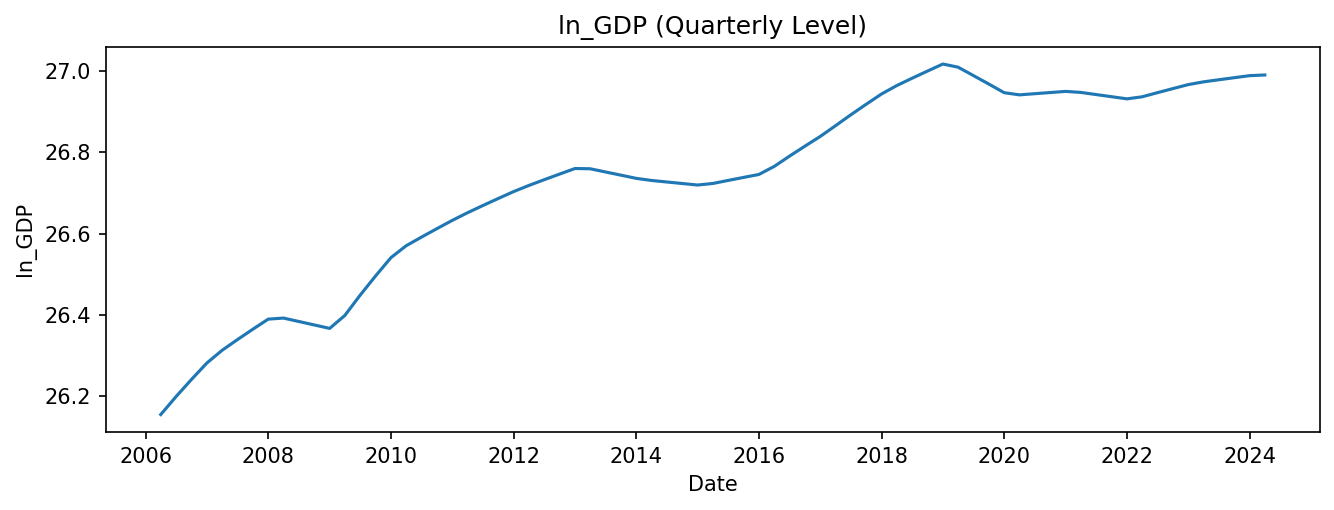

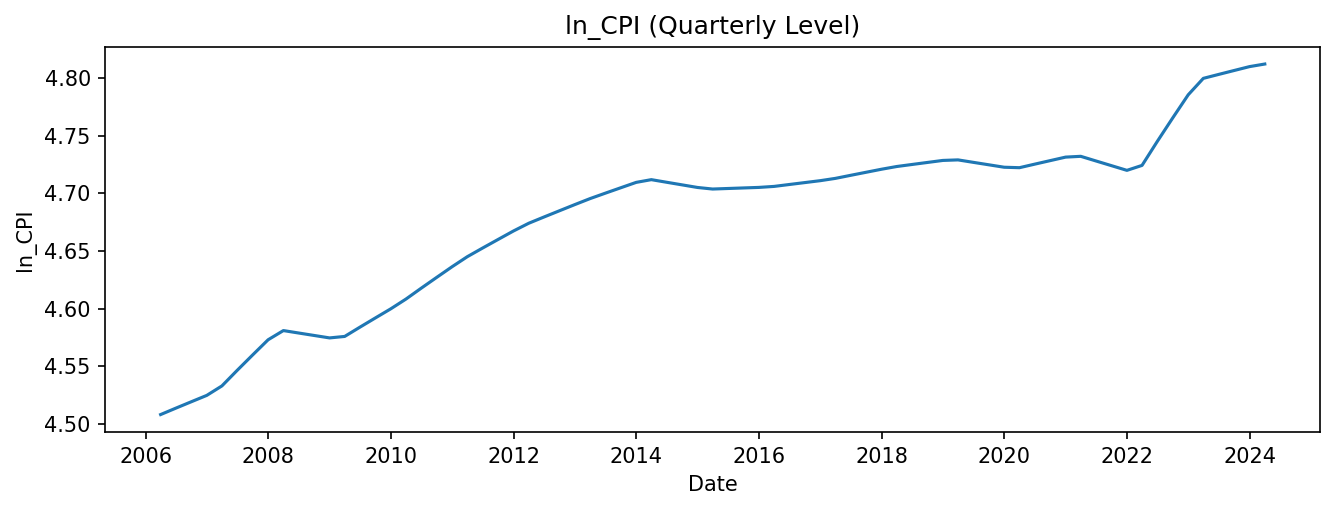

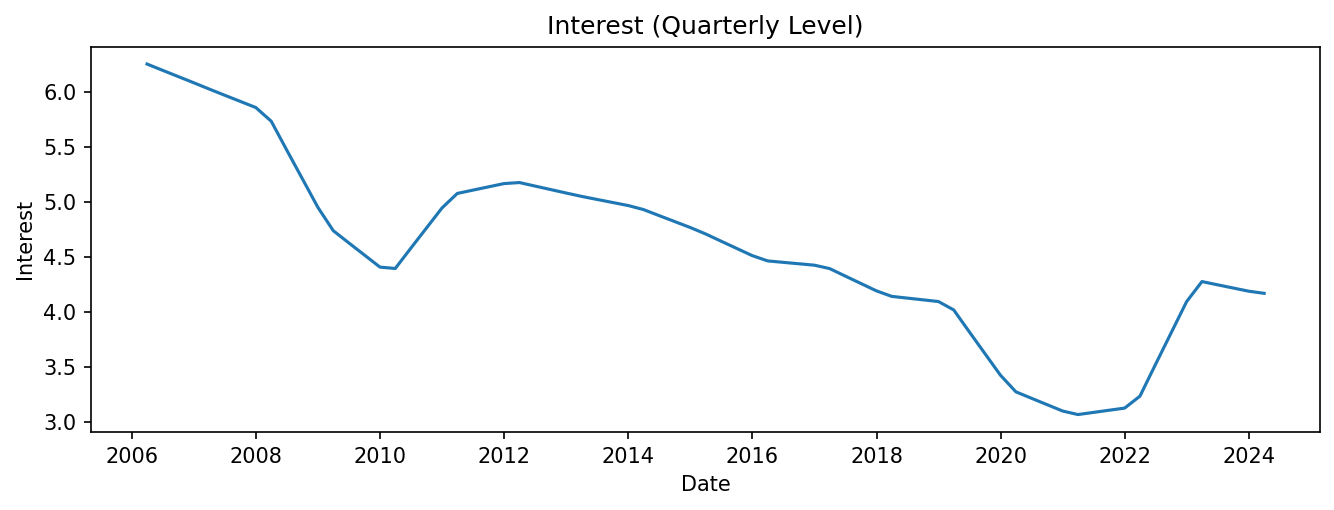

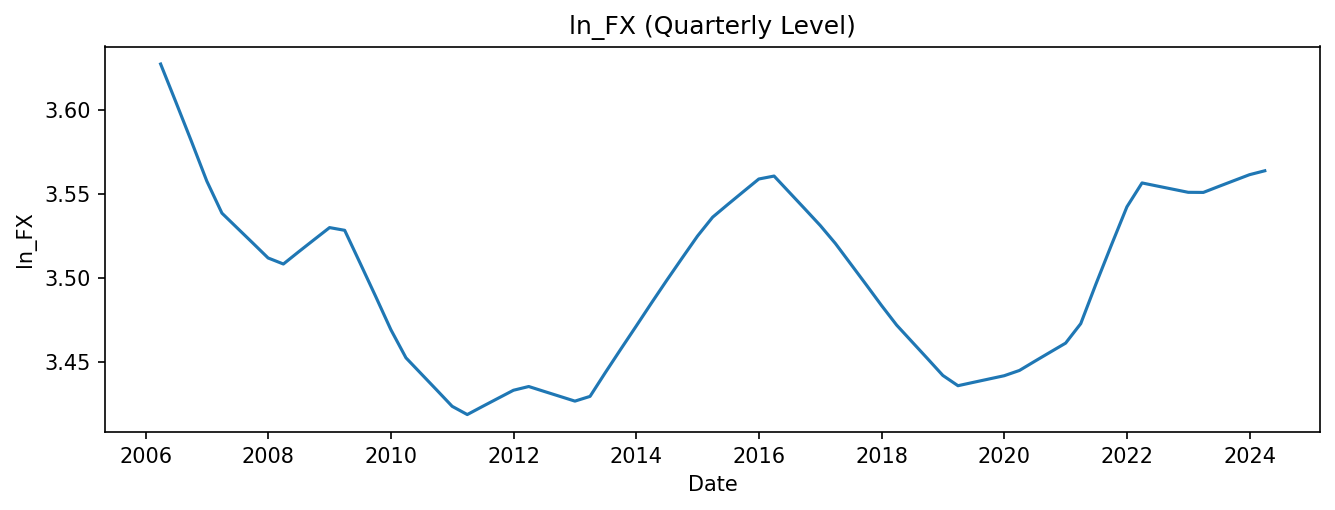

In [3]:
for col in df.columns:
    plt.figure(figsize=(9, 3.5))
    plt.plot(df.index, df[col], color='tab:blue')
    plt.title(f'{col} (Quarterly Level)')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 3. First Difference Construction and Visual Inspection

First-differenced shape: (72, 5)
              ln_WTI   ln_GDP   ln_CPI  Interest     ln_FX
date                                                      
2006-06-30  0.107291 0.044051 0.005578 -0.056810 -0.022619
2006-09-30 -0.002204 0.042192 0.005547 -0.056810 -0.023143
2006-12-31 -0.158414 0.040484 0.005516 -0.056810 -0.023691
2007-03-31 -0.032961 0.031005 0.008202 -0.056597 -0.019006
2007-06-30  0.112854 0.026215 0.013518 -0.056170 -0.008790


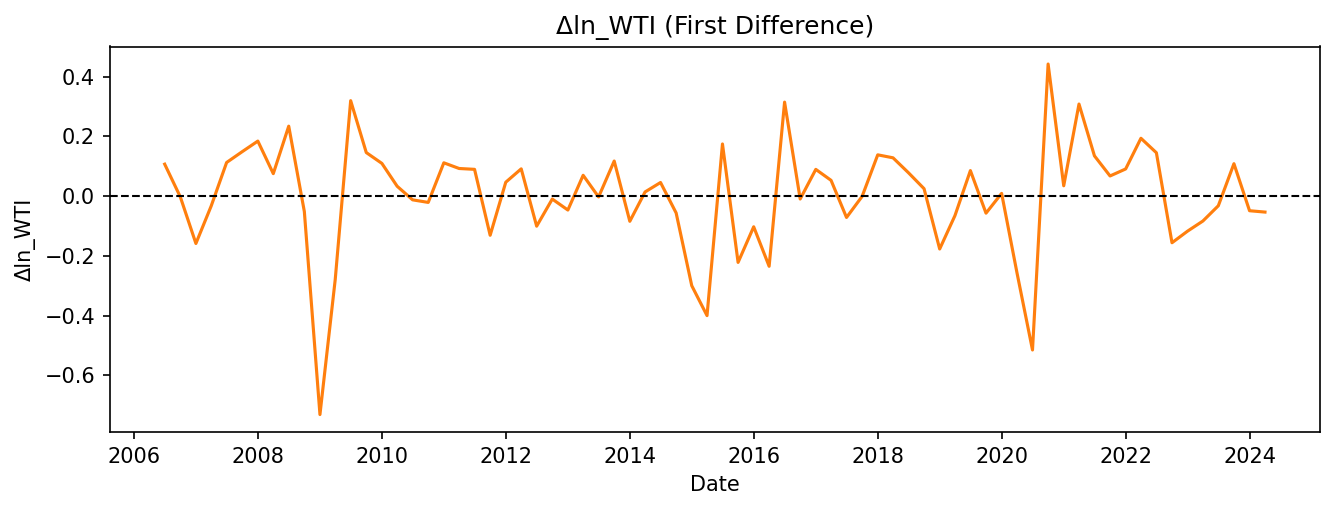

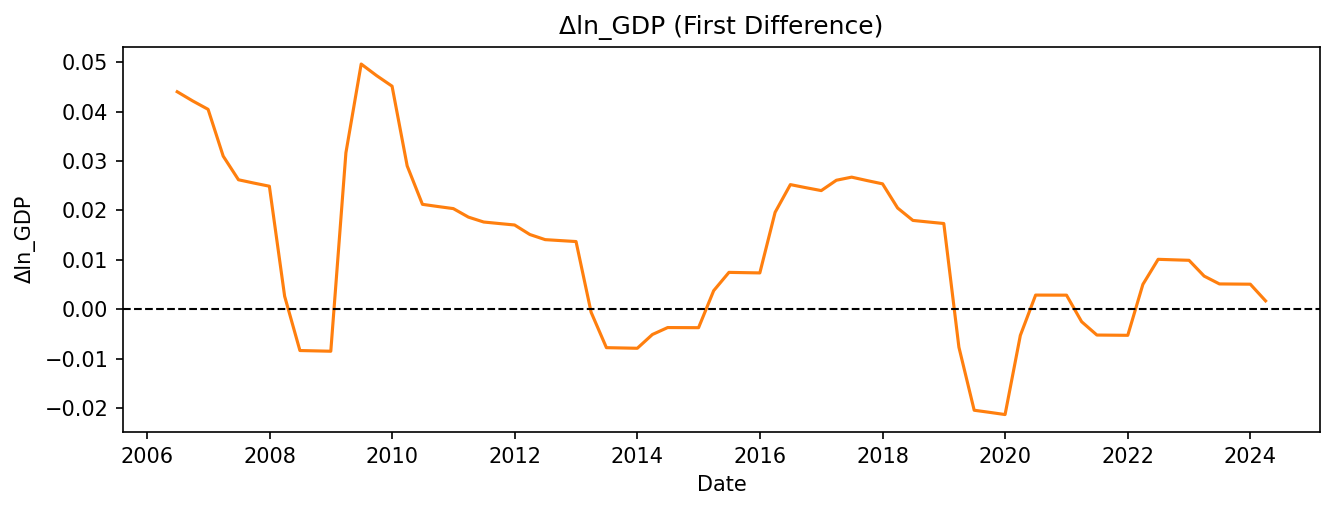

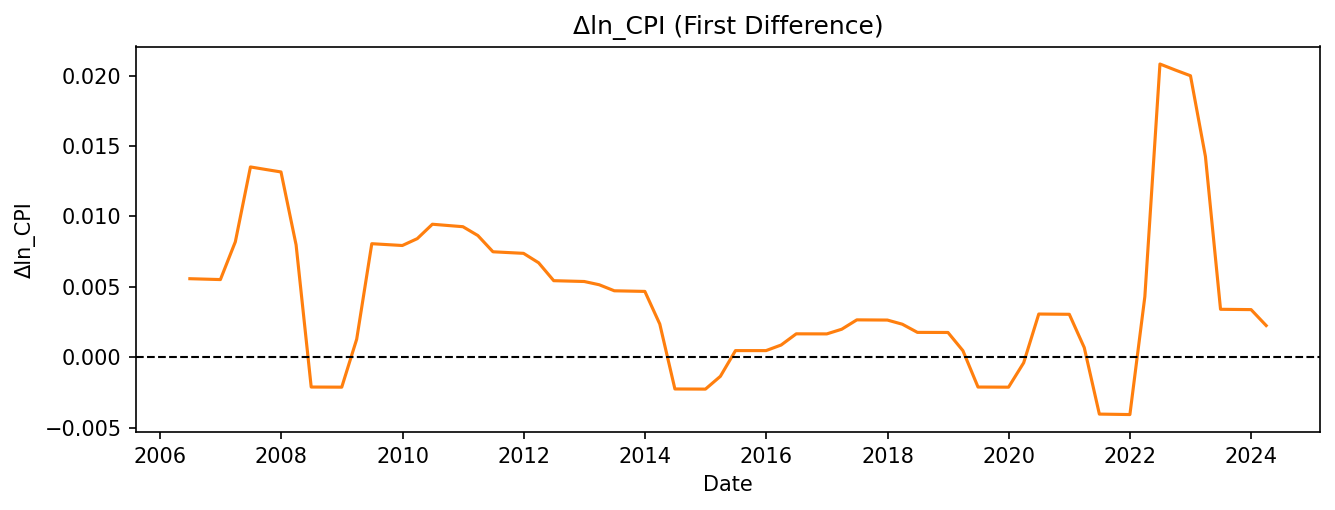

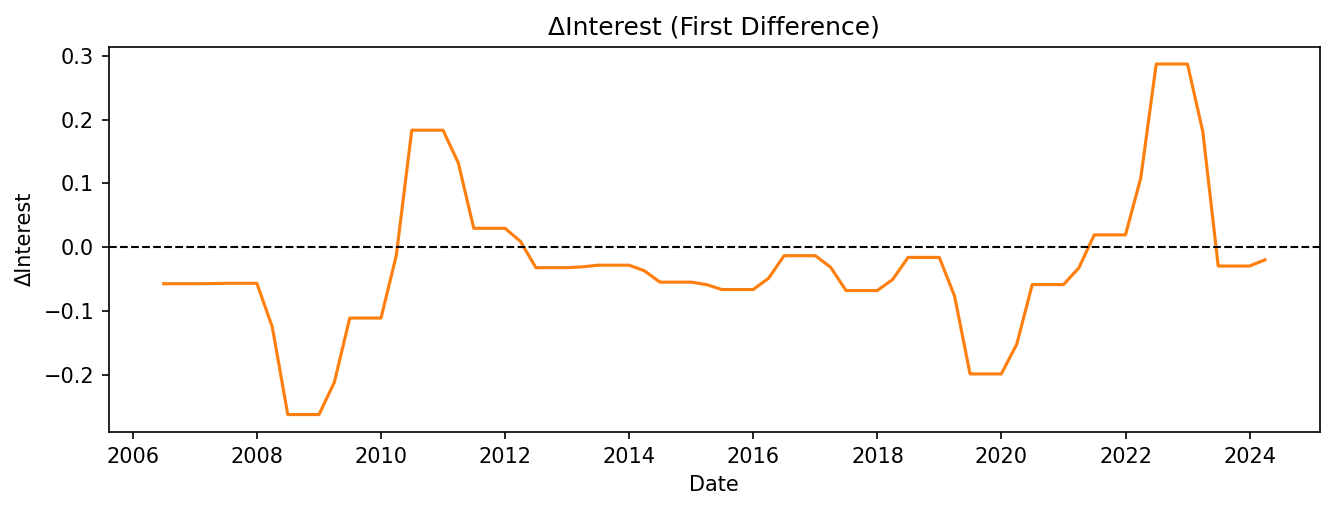

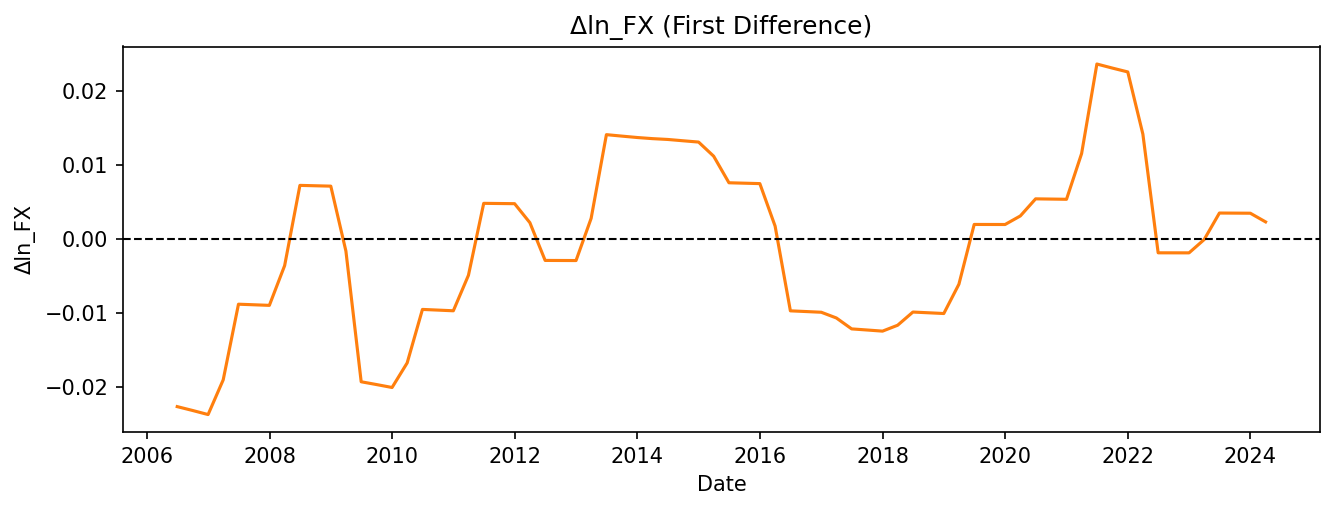

In [4]:
df_diff1 = df.diff().dropna()
print('First-differenced shape:', df_diff1.shape)
print(df_diff1.head())

for col in df_diff1.columns:
    plt.figure(figsize=(9, 3.5))
    plt.plot(df_diff1.index, df_diff1[col], color='tab:orange')
    plt.axhline(0.0, color='black', linewidth=1, linestyle='--')
    plt.title(f'Δ{col} (First Difference)')
    plt.xlabel('Date')
    plt.ylabel(f'Δ{col}')
    plt.tight_layout()
    plt.show()

## 4. Unit Root Test Helpers
Run ADF and KPSS for all variables at level and first difference. If available, also run Phillips-Perron.

In [5]:
def run_adf(series, regression='c'):
    s = series.dropna()
    stat, pval, usedlag, nobs, crit, _ = adfuller(s, autolag='AIC', regression=regression)
    return {'stat': stat, 'pvalue': pval, 'lags': usedlag, 'nobs': nobs, 'crit_5': crit['5%']}

def run_kpss(series, regression='c'):
    s = series.dropna()
    stat, pval, lags, crit = kpss(s, regression=regression, nlags='auto')
    return {'stat': stat, 'pvalue': pval, 'lags': lags, 'crit_5': crit['5%']}

def run_pp(series, regression='c'):
    if not HAS_PP:
        return {'stat': None, 'pvalue': None}
    s = series.dropna()
    trend = 'c' if regression == 'c' else 'ct'
    pp = PhillipsPerron(s, trend=trend)
    return {'stat': pp.stat, 'pvalue': pp.pvalue}

## 5. Stationarity Tests (Level, Diff1, and Diff2 If Needed)

In [6]:
records = []

for col in df.columns:
    # Level
    adf_lvl = run_adf(df[col], regression='c')
    kpss_lvl = run_kpss(df[col], regression='c')
    pp_lvl = run_pp(df[col], regression='c')

    # First difference
    adf_d1 = run_adf(df_diff1[col], regression='c')
    kpss_d1 = run_kpss(df_diff1[col], regression='c')
    pp_d1 = run_pp(df_diff1[col], regression='c')

    # Second difference for unresolved cases
    diff2 = df[col].diff().diff().dropna()
    adf_d2 = run_adf(diff2, regression='c')
    kpss_d2 = run_kpss(diff2, regression='c')
    pp_d2 = run_pp(diff2, regression='c')

    lvl_stationary = (adf_lvl['pvalue'] < 0.05) and (kpss_lvl['pvalue'] > 0.05)
    d1_stationary = (adf_d1['pvalue'] < 0.05) and (kpss_d1['pvalue'] > 0.05)
    d2_stationary = (adf_d2['pvalue'] < 0.05) and (kpss_d2['pvalue'] > 0.05)

    if lvl_stationary:
        integ_order = 'I(0)'
    elif d1_stationary:
        integ_order = 'I(1)'
    elif d2_stationary:
        integ_order = 'I(2)'
    else:
        integ_order = 'Unresolved'

    records.append({
        'Variable': col,
        'ADF_Level_p': adf_lvl['pvalue'],
        'KPSS_Level_p': kpss_lvl['pvalue'],
        'PP_Level_p': pp_lvl['pvalue'],
        'ADF_Diff1_p': adf_d1['pvalue'],
        'KPSS_Diff1_p': kpss_d1['pvalue'],
        'PP_Diff1_p': pp_d1['pvalue'],
        'ADF_Diff2_p': adf_d2['pvalue'],
        'KPSS_Diff2_p': kpss_d2['pvalue'],
        'PP_Diff2_p': pp_d2['pvalue'],
        'Integration_Order': integ_order
    })

results = pd.DataFrame(records)
print('Stationarity test p-values and inferred integration orders:')
print(results.to_string(index=False))

Stationarity test p-values and inferred integration orders:
Variable  ADF_Level_p  KPSS_Level_p  PP_Level_p  ADF_Diff1_p  KPSS_Diff1_p  PP_Diff1_p  ADF_Diff2_p  KPSS_Diff2_p  PP_Diff2_p Integration_Order
  ln_WTI     0.115809      0.100000    0.138444     0.000000      0.100000    0.000000     0.000000      0.100000    0.000000              I(1)
  ln_GDP     0.255406      0.010000    0.011947     0.046470      0.040087    0.105513     0.000000      0.100000    0.000027              I(2)
  ln_CPI     0.776019      0.010000    0.505340     0.055625      0.100000    0.166284     0.000936      0.100000    0.000022              I(2)
Interest     0.231355      0.010000    0.280306     0.005529      0.100000    0.236896     0.000238      0.100000    0.000035              I(1)
   ln_FX     0.000596      0.100000    0.080254     0.006543      0.100000    0.129730     0.000003      0.100000    0.000029              I(0)


/var/folders/bg/hsvxykxj7yx0jz1nrhc3k6z40000gn/T/ipykernel_37502/146029929.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(s, regression=regression, nlags='auto')
/var/folders/bg/hsvxykxj7yx0jz1nrhc3k6z40000gn/T/ipykernel_37502/146029929.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(s, regression=regression, nlags='auto')
/var/folders/bg/hsvxykxj7yx0jz1nrhc3k6z40000gn/T/ipykernel_37502/146029929.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(s, regression=regression, nlags='auto')
/var/folders/bg/hsvxykxj7yx0jz1nrhc3k6z4

## 6. Diagnostic Summary
Interpretation guideline:
- ADF / PP: reject unit root if p < 0.05
- KPSS: reject stationarity if p < 0.05

The `Integration_Order` column provides a transparent diagnostic classification under the quarterly specification.

In [7]:
print(results[['Variable', 'Integration_Order']].to_string(index=False))
print('Counts by integration order:')
print(results['Integration_Order'].value_counts())

Variable Integration_Order
  ln_WTI              I(1)
  ln_GDP              I(2)
  ln_CPI              I(2)
Interest              I(1)
   ln_FX              I(0)
Counts by integration order:
Integration_Order
I(1)    2
I(2)    2
I(0)    1
Name: count, dtype: int64
